# TetheredAI MLB Moneyline: EDA, Feature QA, Model Tuning, and Betting Diagnostics

This notebook is the development/QA workbook for the MLB moneyline model. It reads the same production outputs used by the pipeline:

- `data/odds.db`
- `data/processed/mlb_game_features.parquet`
- optional: `data/predictions/mlb_moneyline_predictions.csv`

The goals are to:

1. validate the data loaded from the pipeline,
2. inspect missingness and leakage risk,
3. evaluate the current feature engineering,
4. compare baseline, starter-enhanced, and matchup-enhanced feature sets,
5. hyperparameter tune several model families,
6. compare probability quality, calibration, and feature importance,
7. review betting diagnostics when historical odds are available.

This version adds optional **XGBoost** and **LightGBM** model families. If those packages are not installed, the notebook will skip them and continue with the scikit-learn models.


## 1. Setup

Run this notebook from either the project root or from the `notebooks/` folder. The path resolver below tries to find your project root automatically.


In [1]:
from __future__ import annotations

from pathlib import Path
import importlib.util
import itertools
import sqlite3
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from IPython.display import display

from sklearn.inspection import permutation_importance
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, HistGradientBoostingClassifier, ExtraTreesClassifier
from sklearn.metrics import (
    accuracy_score,
    brier_score_loss,
    classification_report,
    confusion_matrix,
    log_loss,
    roc_auc_score,
)
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV, TimeSeriesSplit, ParameterGrid
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.calibration import calibration_curve, CalibratedClassifierCV

# Optional gradient boosting libraries. The notebook will skip these if they are not installed.
XGBOOST_AVAILABLE = importlib.util.find_spec("xgboost") is not None
LIGHTGBM_AVAILABLE = importlib.util.find_spec("lightgbm") is not None

if XGBOOST_AVAILABLE:
    from xgboost import XGBClassifier
else:
    XGBClassifier = None

if LIGHTGBM_AVAILABLE:
    from lightgbm import LGBMClassifier
else:
    LGBMClassifier = None

warnings.filterwarnings("ignore", category=FutureWarning)
pd.set_option("display.max_columns", 200)
pd.set_option("display.width", 240)

# Notebook tuning controls. Increase these when you want a deeper search.
RANDOM_STATE = 42
CV_SPLITS = 4
MAX_GRID_COMBINATIONS = 36
RANDOM_SEARCH_ITER = 30
INCLUDE_XGBOOST = True
INCLUDE_LIGHTGBM = True

print("XGBoost available:", XGBOOST_AVAILABLE)
print("LightGBM available:", LIGHTGBM_AVAILABLE)


def find_project_root() -> Path:
    candidates = [Path.cwd(), *Path.cwd().parents]
    for path in candidates:
        if (path / "data").exists() and ((path / "src").exists() or (path / "scripts").exists()):
            return path.resolve()
        if (path / "MLB" / "mlb_betting_app" / "data").exists():
            return (path / "MLB" / "mlb_betting_app").resolve()
    # Fallback: if launched from notebooks, parent is probably project root.
    return Path.cwd().resolve().parent if Path.cwd().name == "notebooks" else Path.cwd().resolve()

PROJECT_ROOT = find_project_root()
DATA_DIR = PROJECT_ROOT / "data"
PROCESSED_DIR = DATA_DIR / "processed"
PRED_DIR = DATA_DIR / "predictions"
DB_PATH = DATA_DIR / "odds.db"
FEATURE_PATH = PROCESSED_DIR / "mlb_game_features.parquet"
PREDICTIONS_PATH = PRED_DIR / "mlb_moneyline_predictions.csv"

print("Project root:", PROJECT_ROOT)
print("Feature path exists:", FEATURE_PATH.exists(), FEATURE_PATH)
print("Database path exists:", DB_PATH.exists(), DB_PATH)
print("Predictions path exists:", PREDICTIONS_PATH.exists(), PREDICTIONS_PATH)


XGBoost available: True
LightGBM available: True
Project root: C:\Users\rfo7799\Desktop\Git\TetheredAI\MLB\mlb_betting_app
Feature path exists: True C:\Users\rfo7799\Desktop\Git\TetheredAI\MLB\mlb_betting_app\data\processed\mlb_game_features.parquet
Database path exists: True C:\Users\rfo7799\Desktop\Git\TetheredAI\MLB\mlb_betting_app\data\odds.db
Predictions path exists: True C:\Users\rfo7799\Desktop\Git\TetheredAI\MLB\mlb_betting_app\data\predictions\mlb_moneyline_predictions.csv


### Optional dependencies for boosted models

To run the XGBoost and LightGBM sections, install these packages in the same environment as this notebook:

```bash
pip install xgboost lightgbm
```

For GitHub Codespaces or GitHub Actions, add the following lines to `requirements.txt`:

```text
xgboost>=2.1.0
lightgbm>=4.3.0
```

The notebook checks whether each package is installed and skips unavailable model families rather than failing.


## 2. Load feature file and database tables

The model is trained from the Parquet feature file. The Parquet file is built from `odds.db`, primarily from the `mlb_games`, `mlb_pitcher_game_stats`, `mlb_team_game_stats`, and odds tables.


In [2]:
if not FEATURE_PATH.exists():
    raise FileNotFoundError(f"Feature file not found: {FEATURE_PATH}")

features = pd.read_parquet(FEATURE_PATH)

# Normalize datetime/date columns where available.
for col in ["official_date", "game_datetime_utc", "created_at_utc", "updated_at_utc"]:
    if col in features.columns:
        features[col] = pd.to_datetime(features[col], errors="coerce", utc=True if "datetime" in col or "utc" in col else False)

completed_features = features[features["target_home_win"].notna()].copy() if "target_home_win" in features.columns else pd.DataFrame()
upcoming_features = features[features["target_home_win"].isna()].copy() if "target_home_win" in features.columns else pd.DataFrame()

print("Feature rows:", len(features))
print("Feature columns:", len(features.columns))
print("Completed rows:", len(completed_features))
print("Upcoming rows:", len(upcoming_features))

if "official_date" in features.columns:
    print("Date range:", features["official_date"].min(), "to", features["official_date"].max())

display(features.head())


Feature rows: 5619
Feature columns: 289
Completed rows: 5402
Upcoming rows: 217
Date range: 2024-05-29 00:00:00 to 2026-09-22 00:00:00


,game_pk,season,game_type,official_date,game_datetime_utc,venue_id,venue_name,home_team_id,home_team_name,home_team_norm,away_team_id,away_team_name,away_team_norm,home_score,away_score,target_home_win,home_margin,total_runs,probable_home_pitcher_id,probable_home_pitcher_name,probable_away_pitcher_id,probable_away_pitcher_name,status_code,detailed_state,abstract_state,home_games_played_to_date,home_rest_days,home_win_season_to_date,home_win_last3,home_win_last5,home_win_last10,home_win_last20,home_runs_for_season_to_date,home_runs_for_last3,home_runs_for_last5,home_runs_for_last10,home_runs_for_last20,home_runs_against_season_to_date,home_runs_against_last3,home_runs_against_last5,home_runs_against_last10,home_runs_against_last20,home_run_diff_season_to_date,home_run_diff_last3,home_run_diff_last5,home_run_diff_last10,home_run_diff_last20,away_games_played_to_date,away_rest_days,away_win_season_to_date,away_win_last3,away_win_last5,away_win_last10,away_win_last20,away_runs_for_season_to_date,away_runs_for_last3,away_runs_for_last5,away_runs_for_last10,away_runs_for_last20,away_runs_against_season_to_date,away_runs_against_last3,away_runs_against_last5,away_runs_against_last10,away_runs_against_last20,away_run_diff_season_to_date,away_run_diff_last3,away_run_diff_last5,away_run_diff_last10,away_run_diff_last20,diff_win_season_to_date,diff_win_last3,diff_win_last5,diff_win_last10,diff_win_last20,diff_runs_for_season_to_date,diff_runs_for_last3,diff_runs_for_last5,diff_runs_for_last10,diff_runs_for_last20,diff_runs_against_season_to_date,diff_runs_against_last3,diff_runs_against_last5,diff_runs_against_last10,diff_runs_against_last20,diff_run_diff_season_to_date,diff_run_diff_last3,diff_run_diff_last5,diff_run_diff_last10,diff_run_diff_last20,diff_rest_days,diff_games_played_to_date,home_starter_pitcher_name,home_starter_pitcher_hand,home_starter_games_to_date,home_starter_days_since_last_start,home_starter_era_season_to_date,home_starter_whip_season_to_date,home_starter_k_per_9_season_to_date,home_starter_bb_per_9_season_to_date,home_starter_hr_per_9_season_to_date,...,diff_starter_era_last10,diff_starter_whip_last10,diff_starter_k_per_9_last10,diff_starter_bb_per_9_last10,diff_starter_hr_per_9_last10,diff_starter_k_minus_bb_per_bf_last10,diff_starter_ip_per_start_last10,diff_starter_pitches_per_start_last10,home_team_vs_hand_games_to_date,home_team_vs_hand_runs_season_to_date,home_team_vs_hand_runs_last10,home_team_vs_hand_runs_last20,home_team_vs_hand_home_runs_season_to_date,home_team_vs_hand_home_runs_last10,home_team_vs_hand_home_runs_last20,home_team_vs_hand_bb_per_ab_season_to_date,home_team_vs_hand_bb_per_ab_last10,home_team_vs_hand_bb_per_ab_last20,home_team_vs_hand_k_per_ab_season_to_date,home_team_vs_hand_k_per_ab_last10,home_team_vs_hand_k_per_ab_last20,home_team_vs_hand_ops_season_to_date,home_team_vs_hand_ops_last10,home_team_vs_hand_ops_last20,home_team_vs_hand_obp_season_to_date,home_team_vs_hand_obp_last10,home_team_vs_hand_obp_last20,home_team_vs_hand_slg_season_to_date,home_team_vs_hand_slg_last10,home_team_vs_hand_slg_last20,home_opp_starter_is_lhp,home_opp_starter_is_rhp,away_team_vs_hand_games_to_date,away_team_vs_hand_runs_season_to_date,away_team_vs_hand_runs_last10,away_team_vs_hand_runs_last20,away_team_vs_hand_home_runs_season_to_date,away_team_vs_hand_home_runs_last10,away_team_vs_hand_home_runs_last20,away_team_vs_hand_bb_per_ab_season_to_date,away_team_vs_hand_bb_per_ab_last10,away_team_vs_hand_bb_per_ab_last20,away_team_vs_hand_k_per_ab_season_to_date,away_team_vs_hand_k_per_ab_last10,away_team_vs_hand_k_per_ab_last20,away_team_vs_hand_ops_season_to_date,away_team_vs_hand_ops_last10,away_team_vs_hand_ops_last20,away_team_vs_hand_obp_season_to_date,away_team_vs_hand_obp_last10,away_team_vs_hand_obp_last20,away_team_vs_hand_slg_season_to_date,away_team_vs_hand_slg_last10,away_team_vs_hand_slg_last20,away_opp_starter_is_lhp,away_opp_starter_is_rhp,diff_team_vs_hand_games_to_date,diff_team_vs_hand_runs

In [3]:
def read_sql_table(db_path: Path, table_name: str) -> pd.DataFrame:
    if not db_path.exists():
        return pd.DataFrame()
    with sqlite3.connect(db_path) as conn:
        try:
            return pd.read_sql_query(f"SELECT * FROM {table_name}", conn)
        except Exception as exc:
            print(f"Could not read {table_name}: {exc}")
            return pd.DataFrame()

mlb_games = read_sql_table(DB_PATH, "mlb_games")
pitcher_stats = read_sql_table(DB_PATH, "mlb_pitcher_game_stats")
team_game_stats = read_sql_table(DB_PATH, "mlb_team_game_stats")
odds_events = read_sql_table(DB_PATH, "odds_events")
odds_snapshots = read_sql_table(DB_PATH, "odds_snapshots")
model_runs = read_sql_table(DB_PATH, "model_runs")
predictions_db = read_sql_table(DB_PATH, "predictions")

for name, df in [
    ("mlb_games", mlb_games),
    ("mlb_pitcher_game_stats", pitcher_stats),
    ("mlb_team_game_stats", team_game_stats),
    ("odds_events", odds_events),
    ("odds_snapshots", odds_snapshots),
    ("model_runs", model_runs),
    ("predictions", predictions_db),
]:
    print(f"{name:28s}: {len(df):,} rows, {len(df.columns):,} columns")


mlb_games                   : 5,610 rows, 28 columns
mlb_pitcher_game_stats      : 48,231 rows, 22 columns
mlb_team_game_stats         : 10,786 rows, 23 columns
odds_events                 : 15 rows, 9 columns
odds_snapshots              : 262 rows, 19 columns
model_runs                  : 3 rows, 14 columns
predictions                 : 390 rows, 17 columns


## 3. Data QA and target distribution

This section confirms the training target and checks whether the home-team win rate looks reasonable. If the target is badly imbalanced or suspiciously constant, stop and inspect the data load before modeling.


count    5402.000000
mean        0.532766
sum      2878.000000
Name: target_home_win, dtype: float64
Home win rate: 0.533


,count,mean
month,,
2024-05,39,0.538462
2024-06,401,0.568579
2024-07,373,0.501340
2024-08,413,0.501211
2024-09,385,0.524675
2024-10,43,0.511628
2025-02,111,0.567568
2025-03,426,0.532864
2025-04,391,0.601023


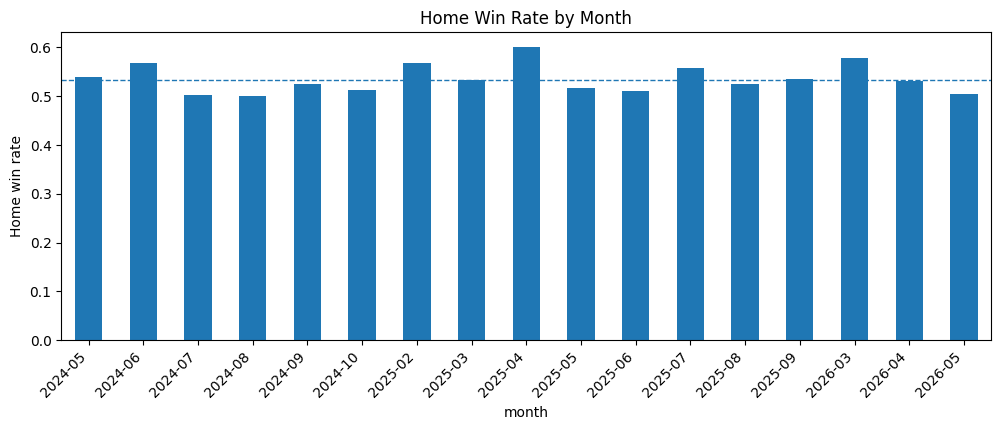

In [4]:
if completed_features.empty:
    raise ValueError("No completed games found. Run scripts/02_fetch_mlb_games.py and scripts/03_build_features.py first.")

completed_features["target_home_win"] = completed_features["target_home_win"].astype(int)

summary = completed_features["target_home_win"].agg(["count", "mean", "sum"])
print(summary)
print("Home win rate:", f"{completed_features['target_home_win'].mean():.3f}")

if "official_date" in completed_features.columns:
    by_month = completed_features.assign(month=completed_features["official_date"].dt.to_period("M"))        .groupby("month")["target_home_win"]        .agg(["count", "mean"])        .tail(24)
    display(by_month)

    ax = by_month["mean"].plot(kind="bar", figsize=(12, 4), title="Home Win Rate by Month")
    ax.axhline(completed_features["target_home_win"].mean(), linestyle="--", linewidth=1)
    ax.set_ylabel("Home win rate")
    plt.xticks(rotation=45, ha="right")
    plt.show()


## 4. Missingness analysis

The historical training set currently has 100% missing market fields because you only recently began collecting odds snapshots. Those fields should stay in the feature file for scoring and future backtesting, but they should be excluded from the current pure-baseball model.


In [5]:
def summarize_missingness(df: pd.DataFrame) -> pd.DataFrame:
    out = pd.DataFrame({
        "column": df.columns,
        "missing_count": df.isna().sum().values,
        "missing_pct": df.isna().mean().values,
        "non_null_count": df.notna().sum().values,
        "dtype": [str(df[c].dtype) for c in df.columns],
    })
    return out.sort_values(["missing_pct", "missing_count"], ascending=False).reset_index(drop=True)

missing_all = summarize_missingness(features)
missing_completed = summarize_missingness(completed_features)

display(missing_completed.head(50))


,column,missing_count,missing_pct,non_null_count,dtype
0,event_id,5402,1.000000,0,object
1,event_date,5402,1.000000,0,object
2,odds_home_team,5402,1.000000,0,object
3,odds_away_team,5402,1.000000,0,object
4,home_moneyline_median,5402,1.000000,0,float64
5,away_moneyline_median,5402,1.000000,0,float64
6,book_count_h2h_home,5402,1.000000,0,float64
7,book_count_h2h_away,5402,1.000000,0,float64
8,market_home_implied_prob,5402,1.000000,0,float64
9,market_away_implied_prob,5402,1.000000,0,float64


In [6]:
market_keywords = [
    "market_", "moneyline", "spread", "total_points", "over_price", "under_price", "book_count", "vig", "odds_"
]

leakage_keywords = [
    "target", "home_score", "away_score", "home_margin", "total_runs",
    "status", "detailed_state", "abstract_state", "coded_game_state",
    "winner", "result"
]

id_or_non_model_cols = [
    "game_pk", "season", "game_type", "official_date", "game_datetime_utc",
    "home_team_id", "away_team_id", "home_team_name", "away_team_name",
    "probable_home_pitcher_id", "probable_away_pitcher_id",
    "probable_home_pitcher_name", "probable_away_pitcher_name",
]

numeric_cols = completed_features.select_dtypes(include=[np.number, "bool"]).columns.tolist()

market_cols = [c for c in numeric_cols if any(k in c.lower() for k in market_keywords)]
leakage_cols = [c for c in numeric_cols if any(k in c.lower() for k in leakage_keywords)]
metadata_cols = [c for c in id_or_non_model_cols if c in numeric_cols]

candidate_feature_cols = [
    c for c in numeric_cols
    if c not in market_cols
    and c not in leakage_cols
    and c not in metadata_cols
]

# Exclude columns with almost no data. Keep low missingness columns; imputation will handle early-season gaps.
min_non_null_rate = 0.05
pure_baseball_feature_cols = [c for c in candidate_feature_cols if completed_features[c].notna().mean() >= min_non_null_rate]

print("Numeric columns:", len(numeric_cols))
print("Market columns excluded:", len(market_cols))
print("Leakage columns excluded:", len(leakage_cols))
print("Metadata columns excluded:", len(metadata_cols))
print("Pure baseball feature columns:", len(pure_baseball_feature_cols))

display(pd.DataFrame({"market_cols_excluded": market_cols}))


Numeric columns: 268
Market columns excluded: 16
Leakage columns excluded: 5
Metadata columns excluded: 6
Pure baseball feature columns: 241


,market_cols_excluded
0,home_moneyline_median
1,away_moneyline_median
2,book_count_h2h_home
3,book_count_h2h_away
4,market_home_implied_prob
5,market_away_implied_prob
6,market_home_no_vig_prob
7,market_away_no_vig_prob
8,market_vig
9,home_spread_median


## 5. Feature groups: baseline vs enhanced

We evaluate multiple feature sets rather than assuming the newest feature set is best.

- **Baseline:** team form, runs, run differential, rest, calendar.
- **Starter enhanced:** baseline plus starter ERA/WHIP/K/BB/HR/rest features.
- **Matchup enhanced:** starter enhanced plus team vs starter handedness features.


In [7]:
def cols_containing(cols: list[str], keywords: list[str]) -> list[str]:
    return [c for c in cols if any(k in c.lower() for k in keywords)]

starter_cols = cols_containing(pure_baseball_feature_cols, ["starter_"])
team_vs_hand_cols = cols_containing(pure_baseball_feature_cols, ["team_vs_hand", "opp_starter_hand"])
calendar_cols = cols_containing(pure_baseball_feature_cols, ["month", "dayofweek", "day_of_week"])
rest_cols = cols_containing(pure_baseball_feature_cols, ["rest"])
team_form_cols = [
    c for c in pure_baseball_feature_cols
    if c not in starter_cols + team_vs_hand_cols
]

baseline_cols = [c for c in team_form_cols if c in pure_baseball_feature_cols]
starter_enhanced_cols = sorted(set(baseline_cols + starter_cols))
matchup_enhanced_cols = sorted(set(starter_enhanced_cols + team_vs_hand_cols))

feature_sets = {
    "baseline_team_form": baseline_cols,
    "starter_enhanced": starter_enhanced_cols,
    "matchup_enhanced": matchup_enhanced_cols,
}

for name, cols in feature_sets.items():
    print(f"{name:24s}: {len(cols):3d} features")

print("Starter feature examples:")
display(pd.Series(starter_cols[:60], name="starter_features"))
print("Team-vs-hand feature examples:")
display(pd.Series(team_vs_hand_cols[:60], name="team_vs_hand_features"))


baseline_team_form      :  69 features
starter_enhanced        : 175 features
matchup_enhanced        : 241 features
Starter feature examples:


0                        home_starter_games_to_date
1                home_starter_days_since_last_start
2                   home_starter_era_season_to_date
3                  home_starter_whip_season_to_date
4               home_starter_k_per_9_season_to_date
5              home_starter_bb_per_9_season_to_date
6              home_starter_hr_per_9_season_to_date
7     home_starter_k_minus_bb_per_bf_season_to_date
8          home_starter_ip_per_start_season_to_date
9     home_starter_pitches_per_start_season_to_date
10                           home_starter_era_last3
11                          home_starter_whip_last3
12                       home_starter_k_per_9_last3
13                      home_starter_bb_per_9_last3
14                      home_starter_hr_per_9_last3
15             home_starter_k_minus_bb_per_bf_last3
16                  home_starter_ip_per_start_last3
17             home_starter_pitches_per_start_last3
18                           home_starter_era_last5
19          

Team-vs-hand feature examples:


0                home_team_vs_hand_games_to_date
1          home_team_vs_hand_runs_season_to_date
2                  home_team_vs_hand_runs_last10
3                  home_team_vs_hand_runs_last20
4     home_team_vs_hand_home_runs_season_to_date
5             home_team_vs_hand_home_runs_last10
6             home_team_vs_hand_home_runs_last20
7     home_team_vs_hand_bb_per_ab_season_to_date
8             home_team_vs_hand_bb_per_ab_last10
9             home_team_vs_hand_bb_per_ab_last20
10     home_team_vs_hand_k_per_ab_season_to_date
11             home_team_vs_hand_k_per_ab_last10
12             home_team_vs_hand_k_per_ab_last20
13          home_team_vs_hand_ops_season_to_date
14                  home_team_vs_hand_ops_last10
15                  home_team_vs_hand_ops_last20
16          home_team_vs_hand_obp_season_to_date
17                  home_team_vs_hand_obp_last10
18                  home_team_vs_hand_obp_last20
19          home_team_vs_hand_slg_season_to_date
20                  

## 6. Correlation and redundancy review

High correlation between feature variants is expected in rolling team-form features. That does not automatically make them bad, but it can make linear models less stable. Regularized logistic regression and tree-based models can handle this better.


Top positive correlations with target_home_win


,corr_with_target
diff_team_vs_hand_obp_season_to_date,0.123877
diff_team_vs_hand_ops_season_to_date,0.109743
diff_run_diff_season_to_date,0.102876
diff_team_vs_hand_runs_season_to_date,0.095637
diff_team_vs_hand_slg_season_to_date,0.095352
diff_win_season_to_date,0.094073
home_team_vs_hand_obp_season_to_date,0.093997
diff_runs_for_season_to_date,0.091715
diff_run_diff_last20,0.087047
diff_team_vs_hand_obp_last20,0.085125


Top negative correlations with target_home_win


,corr_with_target
away_team_vs_hand_ops_last10,-0.053405
diff_starter_whip_season_to_date,-0.054353
away_team_vs_hand_ops_last20,-0.054369
away_team_vs_hand_obp_last10,-0.055466
diff_team_vs_hand_k_per_ab_season_to_date,-0.055747
away_team_vs_hand_obp_last20,-0.056041
diff_starter_whip_last5,-0.056996
away_team_vs_hand_home_runs_season_to_date,-0.057609
away_team_vs_hand_runs_last20,-0.057691
away_run_diff_last10,-0.059110


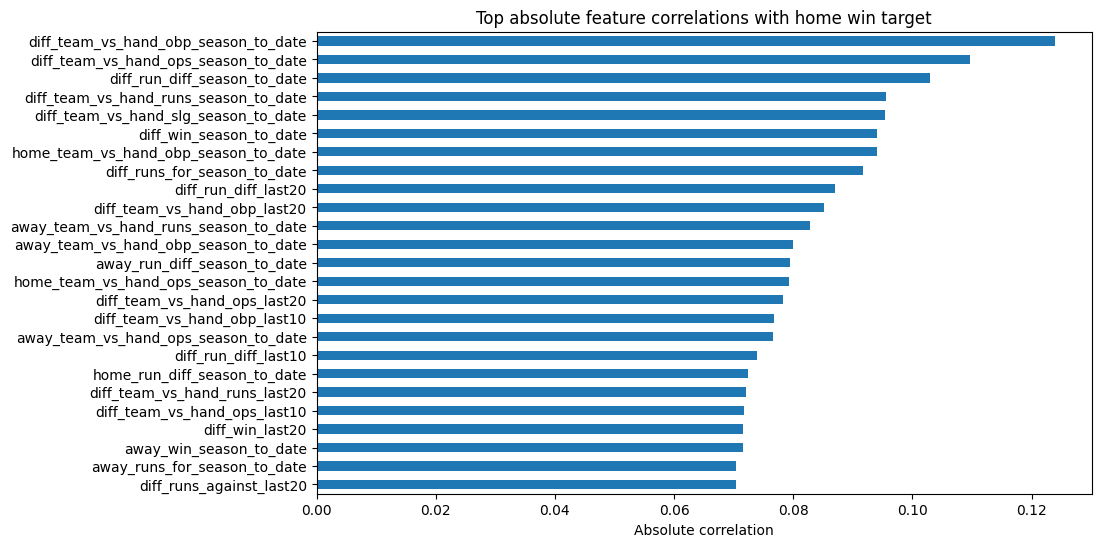

In [8]:
corr_target = completed_features[pure_baseball_feature_cols + ["target_home_win"]].corr(numeric_only=True)["target_home_win"].drop("target_home_win").sort_values(ascending=False)

print("Top positive correlations with target_home_win")
display(corr_target.head(25).to_frame("corr_with_target"))

print("Top negative correlations with target_home_win")
display(corr_target.tail(25).to_frame("corr_with_target"))

fig, ax = plt.subplots(figsize=(10, 6))
corr_target.abs().sort_values(ascending=False).head(25).sort_values().plot(kind="barh", ax=ax)
ax.set_title("Top absolute feature correlations with home win target")
ax.set_xlabel("Absolute correlation")
plt.show()


In [9]:
if "diff_win_last10" in completed_features.columns:
    corr = completed_features[pure_baseball_feature_cols].corr(numeric_only=True)["diff_win_last10"].dropna().sort_values(ascending=False)
    print("Features most correlated with diff_win_last10")
    display(corr.head(20).to_frame("corr_with_diff_win_last10"))
    display(corr.tail(20).to_frame("corr_with_diff_win_last10"))


Features most correlated with diff_win_last10


,corr_with_diff_win_last10
diff_win_last10,1.000000
diff_run_diff_last10,0.810474
diff_win_last20,0.799078
diff_win_last5,0.772063
home_win_last10,0.768014
diff_run_diff_last20,0.684267
diff_win_last3,0.640123
home_run_diff_last10,0.618660
diff_runs_for_last10,0.618425
diff_run_diff_last5,0.617393


,corr_with_diff_win_last10
away_run_diff_season_to_date,-0.336900
home_runs_against_last5,-0.340874
away_runs_for_last5,-0.356604
away_runs_for_last20,-0.356925
home_runs_against_last20,-0.363072
away_win_season_to_date,-0.363887
diff_runs_against_last3,-0.419963
away_run_diff_last3,-0.427320
home_runs_against_last10,-0.430897
away_runs_for_last10,-0.434779


## 7. Time-based train/test split

Sports models should use time-aware validation, not random splits. A random split lets information from future game environments bleed into training.


In [10]:
def make_time_split(df: pd.DataFrame, holdout_days: int = 45) -> tuple[pd.DataFrame, pd.DataFrame]:
    frame = df.copy()
    if "game_datetime_utc" in frame.columns:
        frame["_split_dt"] = pd.to_datetime(frame["game_datetime_utc"], errors="coerce", utc=True)
    elif "official_date" in frame.columns:
        frame["_split_dt"] = pd.to_datetime(frame["official_date"], errors="coerce", utc=True)
    else:
        frame["_split_dt"] = pd.RangeIndex(len(frame))

    frame = frame.sort_values("_split_dt").reset_index(drop=True)
    max_dt = frame["_split_dt"].max()
    cutoff = max_dt - pd.Timedelta(days=holdout_days)
    train = frame[frame["_split_dt"] < cutoff].copy()
    holdout = frame[frame["_split_dt"] >= cutoff].copy()
    return train, holdout

train_df, holdout_df = make_time_split(completed_features, holdout_days=45)

print("Train rows:", len(train_df), train_df["_split_dt"].min(), "to", train_df["_split_dt"].max())
print("Holdout rows:", len(holdout_df), holdout_df["_split_dt"].min(), "to", holdout_df["_split_dt"].max())
print("Train home win rate:", train_df["target_home_win"].mean())
print("Holdout home win rate:", holdout_df["target_home_win"].mean())


Train rows: 4801 2024-05-29 16:40:00+00:00 to 2026-04-13 23:45:00+00:00
Holdout rows: 601 2026-04-14 01:40:00+00:00 to 2026-05-29 00:05:00+00:00
Train home win rate: 0.5359300145802958
Holdout home win rate: 0.5074875207986689


## 8. Model definitions and hyperparameter tuning

We optimize probabilistic quality first using log loss. For betting applications, well-calibrated probabilities are more useful than raw accuracy.

This section now includes:

- Logistic Regression
- Random Forest
- Histogram Gradient Boosting
- Extra Trees
- XGBoost, if installed
- LightGBM, if installed

Large grids are automatically switched from exhaustive `GridSearchCV` to `RandomizedSearchCV` using the controls defined in setup: `MAX_GRID_COMBINATIONS` and `RANDOM_SEARCH_ITER`.


In [12]:
def count_grid_combinations(param_grid: dict) -> int:
    """Count combinations in a simple scikit-learn parameter grid."""
    try:
        return len(list(ParameterGrid(param_grid)))
    except Exception:
        total = 1
        for values in param_grid.values():
            total *= len(values) if isinstance(values, (list, tuple)) else 1
        return total


def make_models(random_state: int = RANDOM_STATE) -> dict[str, tuple[Pipeline, dict]]:
    """
    Return model pipelines and tuning grids.

    Notes:
    - All models use only the feature columns selected earlier.
    - Imputation is inside the pipeline so train/CV folds do not leak holdout medians.
    - XGBoost/LightGBM are optional and are added only when installed.
    """
    models = {}

    logit = Pipeline([
        ("imputer", SimpleImputer(strategy="median", add_indicator=True)),
        ("scaler", StandardScaler()),
        ("model", LogisticRegression(max_iter=5000, solver="lbfgs", random_state=random_state)),
    ])
    logit_grid = {
        "model__C": [0.03, 0.1, 0.3, 1.0, 3.0],
        "model__class_weight": [None, "balanced"],
    }
    models["logistic_regression"] = (logit, logit_grid)

    rf = Pipeline([
        ("imputer", SimpleImputer(strategy="median", add_indicator=True)),
        ("model", RandomForestClassifier(random_state=random_state, n_jobs=-1)),
    ])
    rf_grid = {
        "model__n_estimators": [250, 500],
        "model__max_depth": [4, 6, 10, None],
        "model__min_samples_leaf": [5, 20, 50],
        "model__max_features": ["sqrt", 0.5],
    }
    models["random_forest"] = (rf, rf_grid)

    hgb = Pipeline([
        ("imputer", SimpleImputer(strategy="median", add_indicator=True)),
        ("model", HistGradientBoostingClassifier(random_state=random_state, early_stopping=True)),
    ])
    hgb_grid = {
        "model__learning_rate": [0.02, 0.04, 0.08],
        "model__max_iter": [150, 300, 500],
        "model__max_leaf_nodes": [15, 31, 63],
        "model__l2_regularization": [0.0, 0.1, 1.0],
    }
    models["hist_gradient_boosting"] = (hgb, hgb_grid)

    extra = Pipeline([
        ("imputer", SimpleImputer(strategy="median", add_indicator=True)),
        ("model", ExtraTreesClassifier(random_state=random_state, n_jobs=-1)),
    ])
    extra_grid = {
        "model__n_estimators": [250, 500],
        "model__max_depth": [4, 8, None],
        "model__min_samples_leaf": [5, 20, 50],
        "model__max_features": ["sqrt", 0.5],
    }
    models["extra_trees"] = (extra, extra_grid)

    if INCLUDE_XGBOOST and XGBOOST_AVAILABLE:
        xgb = Pipeline([
            ("imputer", SimpleImputer(strategy="median", add_indicator=True)),
            ("model", XGBClassifier(
                objective="binary:logistic",
                eval_metric="logloss",
                tree_method="hist",
                random_state=random_state,
                n_jobs=-1,
                verbosity=0,
            )),
        ])
        # Designed to be useful without being painfully slow in GitHub/Codespaces.
        xgb_grid = {
            "model__n_estimators": [150, 300, 500],
            "model__max_depth": [2, 3, 4],
            "model__learning_rate": [0.02, 0.05, 0.08],
            "model__subsample": [0.8, 1.0],
            "model__colsample_bytree": [0.8, 1.0],
            "model__min_child_weight": [1, 5],
            "model__reg_lambda": [1.0, 5.0],
        }
        models["xgboost"] = (xgb, xgb_grid)
    elif INCLUDE_XGBOOST:
        print("Skipping XGBoost: package not installed. Install with `pip install xgboost`.")

    if INCLUDE_LIGHTGBM and LIGHTGBM_AVAILABLE:
        lgbm = Pipeline([
            ("imputer", SimpleImputer(strategy="median", add_indicator=True)),
            ("model", LGBMClassifier(
                objective="binary",
                random_state=random_state,
                n_jobs=-1,
                verbosity=-1,
                importance_type="gain",
            )),
        ])
        lgbm_grid = {
            "model__n_estimators": [150, 300, 500],
            "model__num_leaves": [15, 31, 63],
            "model__max_depth": [3, 5, -1],
            "model__learning_rate": [0.02, 0.05, 0.08],
            "model__min_child_samples": [15, 30, 60],
            "model__subsample": [0.8, 1.0],
            "model__colsample_bytree": [0.8, 1.0],
            "model__reg_lambda": [0.0, 1.0, 5.0],
        }
        models["lightgbm"] = (lgbm, lgbm_grid)
    elif INCLUDE_LIGHTGBM:
        print("Skipping LightGBM: package not installed. Install with `pip install lightgbm`.")

    return models


def evaluate_classifier(name: str, estimator, X: pd.DataFrame, y: pd.Series) -> dict:
    proba = estimator.predict_proba(X)[:, 1]
    pred = (proba >= 0.5).astype(int)
    return {
        "model": name,
        "rows": len(y),
        "log_loss": log_loss(y, proba, labels=[0, 1]),
        "brier": brier_score_loss(y, proba),
        "auc": roc_auc_score(y, proba) if len(np.unique(y)) == 2 else np.nan,
        "accuracy": accuracy_score(y, pred),
        "avg_pred_home_win_prob": float(np.mean(proba)),
        "actual_home_win_rate": float(np.mean(y)),
    }


def run_search(pipe, param_grid: dict, X_train: pd.DataFrame, y_train: pd.Series, tscv, model_name: str):
    """Use GridSearchCV for small grids and RandomizedSearchCV for larger grids."""
    combos = count_grid_combinations(param_grid)
    if combos <= MAX_GRID_COMBINATIONS:
        print(f"  Search type: GridSearchCV ({combos} combinations)")
        search = GridSearchCV(
            estimator=pipe,
            param_grid=param_grid,
            scoring="neg_log_loss",
            cv=tscv,
            n_jobs=-1,
            refit=True,
            verbose=0,
        )
    else:
        n_iter = min(RANDOM_SEARCH_ITER, combos)
        print(f"  Search type: RandomizedSearchCV ({n_iter} of {combos} combinations)")
        search = RandomizedSearchCV(
            estimator=pipe,
            param_distributions=param_grid,
            n_iter=n_iter,
            scoring="neg_log_loss",
            cv=tscv,
            n_jobs=-1,
            random_state=RANDOM_STATE,
            refit=True,
            verbose=0,
        )

    search.fit(X_train, y_train)
    return search


def tune_feature_set(train: pd.DataFrame, holdout: pd.DataFrame, cols: list[str], set_name: str, cv_splits: int = CV_SPLITS) -> tuple[pd.DataFrame, dict]:
    X_train = train[cols]
    y_train = train["target_home_win"].astype(int)
    X_holdout = holdout[cols]
    y_holdout = holdout["target_home_win"].astype(int)

    # TimeSeriesSplit preserves order inside the already time-sorted training frame.
    tscv = TimeSeriesSplit(n_splits=cv_splits)
    results = []
    fitted = {}

    for model_name, (pipe, grid) in make_models().items():
        print(f"Tuning {set_name} / {model_name} ...")
        search = run_search(pipe, grid, X_train, y_train, tscv, model_name=model_name)
        metrics = evaluate_classifier(f"{set_name}__{model_name}", search.best_estimator_, X_holdout, y_holdout)
        metrics["feature_set"] = set_name
        metrics["model_family"] = model_name
        metrics["feature_count"] = len(cols)
        metrics["search_type"] = type(search).__name__
        metrics["param_combinations"] = count_grid_combinations(grid)
        metrics["best_cv_neg_log_loss"] = search.best_score_
        metrics["best_params"] = search.best_params_
        results.append(metrics)
        fitted[f"{set_name}__{model_name}"] = search.best_estimator_

    return pd.DataFrame(results).sort_values("log_loss"), fitted


### Run model comparison

This can take a few minutes. To speed it up during development, start with `feature_sets_to_run = ["baseline_team_form", "matchup_enhanced"]`.


Tuning baseline_team_form / logistic_regression ...
  Search type: GridSearchCV (10 combinations)
Tuning baseline_team_form / random_forest ...
  Search type: RandomizedSearchCV (30 of 48 combinations)
Tuning baseline_team_form / hist_gradient_boosting ...
  Search type: RandomizedSearchCV (30 of 81 combinations)
Tuning baseline_team_form / extra_trees ...
  Search type: GridSearchCV (36 combinations)
Tuning baseline_team_form / xgboost ...
  Search type: RandomizedSearchCV (30 of 432 combinations)
Tuning baseline_team_form / lightgbm ...
  Search type: RandomizedSearchCV (30 of 2916 combinations)


C:\Users\rfo7799\AppData\Roaming\Python\Python311\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


Tuning starter_enhanced / logistic_regression ...
  Search type: GridSearchCV (10 combinations)
Tuning starter_enhanced / random_forest ...
  Search type: RandomizedSearchCV (30 of 48 combinations)
Tuning starter_enhanced / hist_gradient_boosting ...
  Search type: RandomizedSearchCV (30 of 81 combinations)
Tuning starter_enhanced / extra_trees ...
  Search type: GridSearchCV (36 combinations)
Tuning starter_enhanced / xgboost ...
  Search type: RandomizedSearchCV (30 of 432 combinations)
Tuning starter_enhanced / lightgbm ...
  Search type: RandomizedSearchCV (30 of 2916 combinations)


C:\Users\rfo7799\AppData\Roaming\Python\Python311\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


Tuning matchup_enhanced / logistic_regression ...
  Search type: GridSearchCV (10 combinations)
Tuning matchup_enhanced / random_forest ...
  Search type: RandomizedSearchCV (30 of 48 combinations)
Tuning matchup_enhanced / hist_gradient_boosting ...
  Search type: RandomizedSearchCV (30 of 81 combinations)
Tuning matchup_enhanced / extra_trees ...
  Search type: GridSearchCV (36 combinations)
Tuning matchup_enhanced / xgboost ...
  Search type: RandomizedSearchCV (30 of 432 combinations)
Tuning matchup_enhanced / lightgbm ...
  Search type: RandomizedSearchCV (30 of 2916 combinations)


C:\Users\rfo7799\AppData\Roaming\Python\Python311\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


,feature_set,model_family,feature_count,search_type,param_combinations,log_loss,brier,auc,accuracy,avg_pred_home_win_prob,actual_home_win_rate,best_cv_neg_log_loss,best_params
0,baseline_team_form,random_forest,69,RandomizedSearchCV,48,0.687675,0.247294,0.573294,0.527454,0.537338,0.507488,-0.685540,"{'model__n_estimators': 500, 'model__min_sampl..."
12,matchup_enhanced,random_forest,241,RandomizedSearchCV,48,0.687989,0.247441,0.567833,0.545757,0.536426,0.507488,-0.683809,"{'model__n_estimators': 500, 'model__min_sampl..."
13,matchup_enhanced,xgboost,241,RandomizedSearchCV,432,0.688379,0.247651,0.559149,0.509151,0.535566,0.507488,-0.687174,"{'model__subsample': 1.0, 'model__reg_lambda':..."
1,baseline_team_form,extra_trees,69,GridSearchCV,36,0.688484,0.247698,0.567867,0.525790,0.536944,0.507488,-0.686235,"{'model__max_depth': 4, 'model__max_features':..."
6,starter_enhanced,random_forest,175,RandomizedSearchCV,48,0.688706,0.247806,0.559991,0.540765,0.534763,0.507488,-0.684538,"{'model__n_estimators': 500, 'model__min_sampl..."
14,matchup_enhanced,extra_trees,241,GridSearchCV,36,0.689572,0.248230,0.561187,0.520799,0.536722,0.507488,-0.683913,"{'model__max_depth': 8, 'model__max_features':..."
7,starter_enhanced,extra_trees,175,GridSearchCV,36,0.690085,0.248496,0.552105,0.530782,0.538655,0.507488,-0.685053,"{'model__max_depth': 8, 'model__max_features':..."
2,baseline_team_form,xgboost,69,RandomizedSearchCV,432,0.691420,0.249115,0.544478,0.529118,0.539284,0.507488,-0.688651,"{'model__subsample': 1.0, 'model__reg_lambda':..."
8,starter_enhanced,xgboost,175,RandomizedSearchCV,432,0.692389,0.249630,0.538901,0.515807,0.539372,0.507488,-0.686512,"{'model__subsample': 1.0, 'model__reg_lambda':..."
15,matchup_enhanced,lightgbm,241,RandomizedSearchCV,2916,0.693691,0.250256,0.535689,0.522463,0.534501,0.507488,-0.696154,"{'model__subsample': 0.8, 'model__reg_lambda':..."


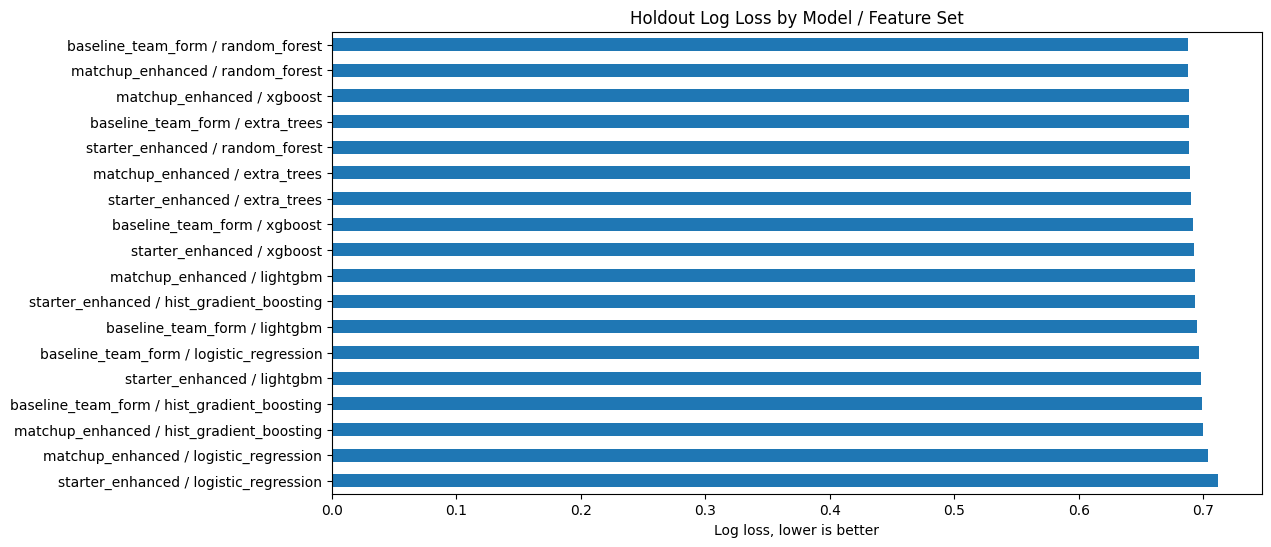

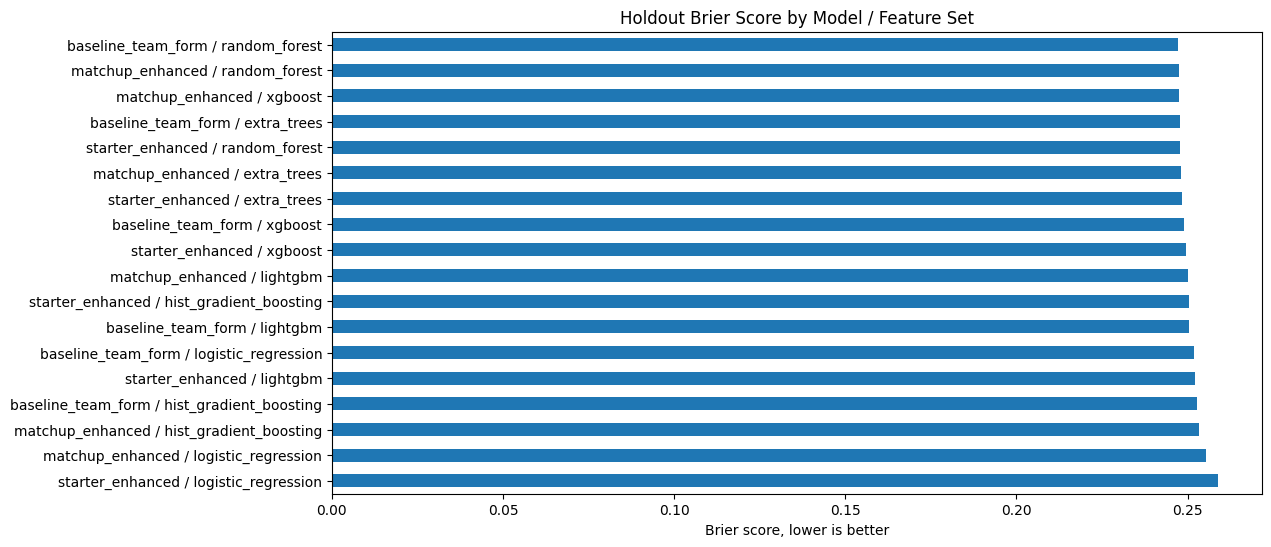

In [13]:
feature_sets_to_run = [name for name, cols in feature_sets.items() if len(cols) > 0]

all_results = []
all_fitted = {}

for set_name in feature_sets_to_run:
    result_df, fitted_models = tune_feature_set(train_df, holdout_df, feature_sets[set_name], set_name=set_name, cv_splits=CV_SPLITS)
    all_results.append(result_df)
    all_fitted.update(fitted_models)

results = pd.concat(all_results, ignore_index=True).sort_values("log_loss")
result_cols = [
    "feature_set", "model_family", "feature_count", "search_type", "param_combinations",
    "log_loss", "brier", "auc", "accuracy", "avg_pred_home_win_prob",
    "actual_home_win_rate", "best_cv_neg_log_loss", "best_params"
]
display(results[result_cols])

# Visual model comparison.
fig, ax = plt.subplots(figsize=(12, 6))
plot_df = results.sort_values("log_loss", ascending=True).copy()
plot_df["label"] = plot_df["feature_set"] + " / " + plot_df["model_family"]
plot_df.head(20).sort_values("log_loss", ascending=False).plot(
    x="label", y="log_loss", kind="barh", ax=ax, legend=False
)
ax.set_title("Holdout Log Loss by Model / Feature Set")
ax.set_xlabel("Log loss, lower is better")
ax.set_ylabel("")
plt.show()

fig, ax = plt.subplots(figsize=(12, 6))
plot_df.head(20).sort_values("brier", ascending=False).plot(
    x="label", y="brier", kind="barh", ax=ax, legend=False
)
ax.set_title("Holdout Brier Score by Model / Feature Set")
ax.set_xlabel("Brier score, lower is better")
ax.set_ylabel("")
plt.show()


### Boosted-model notes

XGBoost and LightGBM are both gradient boosting tree libraries. They can outperform the scikit-learn baselines when there are nonlinear interactions, but they can also overfit small or noisy feature sets. For sports betting, compare them primarily on **log loss**, **Brier score**, and **calibration**, not just accuracy.

Useful comparisons:

- Does XGBoost/LightGBM beat logistic regression on holdout log loss?
- Does it remain calibrated, or does it produce overconfident probabilities?
- Are the best features plausible baseball signals rather than artifacts?


In [14]:
boosted_families = {"xgboost", "lightgbm", "hist_gradient_boosting"}
boosted_results = results[results["model_family"].isin(boosted_families)].copy()

if boosted_results.empty:
    print("No boosted model results available. Install xgboost/lightgbm or rerun the model comparison.")
else:
    display(boosted_results[[
        "feature_set", "model_family", "feature_count", "search_type", "log_loss", "brier", "auc", "accuracy", "best_params"
    ]].sort_values("log_loss"))

    pivot = results.pivot_table(index="model_family", columns="feature_set", values="log_loss", aggfunc="min")
    display(pivot.sort_index())


,feature_set,model_family,feature_count,search_type,log_loss,brier,auc,accuracy,best_params
13,matchup_enhanced,xgboost,241,RandomizedSearchCV,0.688379,0.247651,0.559149,0.509151,"{'model__subsample': 1.0, 'model__reg_lambda':..."
2,baseline_team_form,xgboost,69,RandomizedSearchCV,0.691420,0.249115,0.544478,0.529118,"{'model__subsample': 1.0, 'model__reg_lambda':..."
8,starter_enhanced,xgboost,175,RandomizedSearchCV,0.692389,0.249630,0.538901,0.515807,"{'model__subsample': 1.0, 'model__reg_lambda':..."
15,matchup_enhanced,lightgbm,241,RandomizedSearchCV,0.693691,0.250256,0.535689,0.522463,"{'model__subsample': 0.8, 'model__reg_lambda':..."
9,starter_enhanced,hist_gradient_boosting,175,RandomizedSearchCV,0.693707,0.250293,0.540862,0.515807,"{'model__max_leaf_nodes': 15, 'model__max_iter..."
3,baseline_team_form,lightgbm,69,RandomizedSearchCV,0.694642,0.250522,0.541848,0.545757,"{'model__subsample': 0.8, 'model__reg_lambda':..."
10,starter_enhanced,lightgbm,175,RandomizedSearchCV,0.698045,0.252332,0.534736,0.530782,"{'model__subsample': 0.8, 'model__reg_lambda':..."
5,baseline_team_form,hist_gradient_boosting,69,RandomizedSearchCV,0.698939,0.252861,0.514178,0.509151,"{'model__max_leaf_nodes': 15, 'model__max_iter..."
16,matchup_enhanced,hist_gradient_boosting,241,RandomizedSearchCV,0.700110,0.253236,0.530871,0.527454,"{'model__max_leaf_nodes': 31, 'model__max_iter..."


feature_set,baseline_team_form,matchup_enhanced,starter_enhanced
model_family,,,
extra_trees,0.688484,0.689572,0.690085
hist_gradient_boosting,0.698939,0.700110,0.693707
lightgbm,0.694642,0.693691,0.698045
logistic_regression,0.696955,0.704110,0.711534
random_forest,0.687675,0.687989,0.688706
xgboost,0.691420,0.688379,0.692389


## 9. Select best model and evaluate calibration

The best model by log loss is usually the best starting point, but calibration matters heavily for expected-value betting.


In [17]:
best_row = results.iloc[0]
best_key = f"{best_row['feature_set']}__{best_row['model_family']}"
best_model = all_fitted[best_key]
best_feature_cols = feature_sets[best_row["feature_set"]]

X_holdout = holdout_df[best_feature_cols]
y_holdout = holdout_df["target_home_win"].astype(int)
holdout_proba = best_model.predict_proba(X_holdout)[:, 1]
holdout_pred = (holdout_proba >= 0.5).astype(int)

print("Best model:", best_key)
print("Feature count:", len(best_feature_cols))
print("Best params:", best_row["best_params"])
print("Classification report:")
print(classification_report(y_holdout, holdout_pred, digits=3))
print("Confusion matrix:")
display(pd.DataFrame(confusion_matrix(y_holdout, holdout_pred), index=["actual_away", "actual_home"], columns=["pred_away", "pred_home"]))


Best model: baseline_team_form__random_forest
Feature count: 69
Best params: {'model__n_estimators': 500, 'model__min_samples_leaf': 50, 'model__max_features': 'sqrt', 'model__max_depth': 4}
Classification report:
              precision    recall  f1-score   support

           0      0.564     0.179     0.272       296
           1      0.521     0.866     0.650       305

    accuracy                          0.527       601
   macro avg      0.542     0.522     0.461       601
weighted avg      0.542     0.527     0.464       601

Confusion matrix:


,pred_away,pred_home
actual_away,53,243
actual_home,41,264


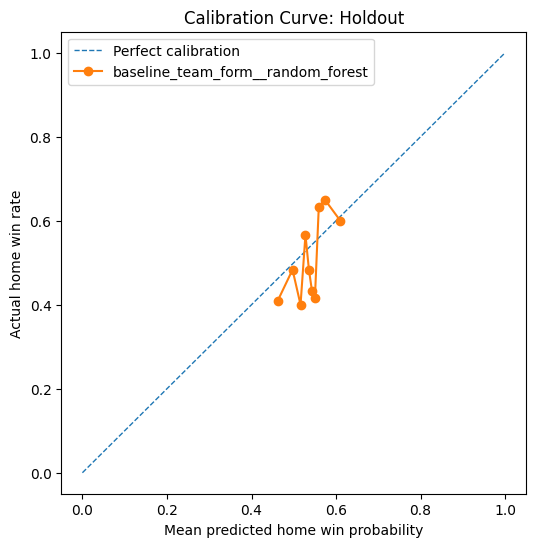

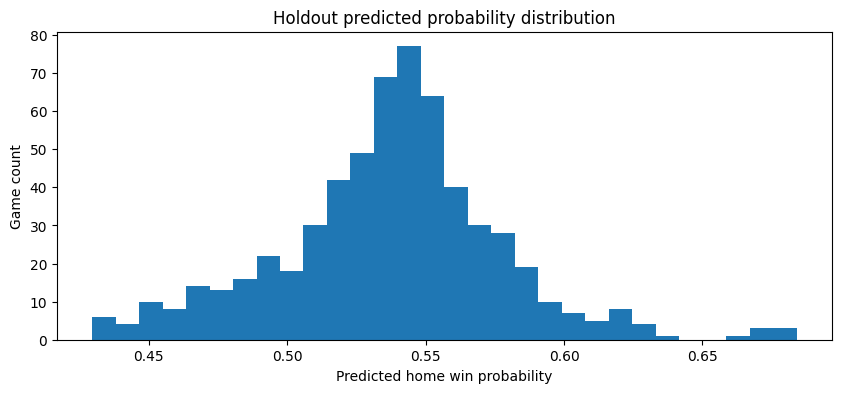

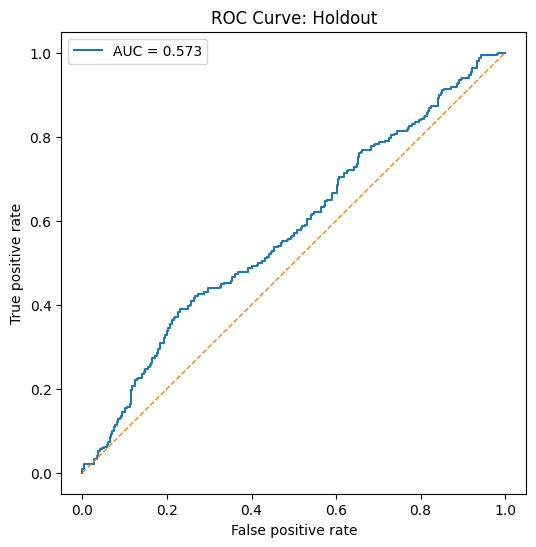

In [18]:
from sklearn.metrics import roc_curve

# Calibration plot
frac_pos, mean_pred = calibration_curve(y_holdout, holdout_proba, n_bins=10, strategy="quantile")

fig, ax = plt.subplots(figsize=(6, 6))
ax.plot([0, 1], [0, 1], linestyle="--", linewidth=1, label="Perfect calibration")
ax.plot(mean_pred, frac_pos, marker="o", label=best_key)
ax.set_title("Calibration Curve: Holdout")
ax.set_xlabel("Mean predicted home win probability")
ax.set_ylabel("Actual home win rate")
ax.legend()
plt.show()

# Distribution of probabilities
fig, ax = plt.subplots(figsize=(10, 4))
ax.hist(holdout_proba, bins=30)
ax.set_title("Holdout predicted probability distribution")
ax.set_xlabel("Predicted home win probability")
ax.set_ylabel("Game count")
plt.show()

# ROC curve
fpr, tpr, thresholds = roc_curve(y_holdout, holdout_proba)
fig, ax = plt.subplots(figsize=(6, 6))
ax.plot(fpr, tpr, label=f"AUC = {roc_auc_score(y_holdout, holdout_proba):.3f}")
ax.plot([0, 1], [0, 1], linestyle="--", linewidth=1)
ax.set_title("ROC Curve: Holdout")
ax.set_xlabel("False positive rate")
ax.set_ylabel("True positive rate")
ax.legend()
plt.show()


## 10. Probability buckets

This is often more useful than accuracy. If the model says 60–65%, the actual win rate should be close to that range over time.


,games,avg_pred_prob,actual_home_win_rate,calibration_error
prob_bucket,,,,
"(-0.001, 0.35]",0,NaN,NaN,NaN
"(0.35, 0.4]",0,NaN,NaN,NaN
"(0.4, 0.45]",14,0.440188,0.142857,-0.297331
"(0.45, 0.5]",80,0.477861,0.487500,0.009639
"(0.5, 0.55]",301,0.530274,0.455150,-0.075124
"(0.55, 0.6]",175,0.568112,0.628571,0.060459
"(0.6, 0.65]",24,0.616483,0.458333,-0.158149
"(0.65, 0.7]",7,0.674416,0.857143,0.182727
"(0.7, 1.0]",0,NaN,NaN,NaN


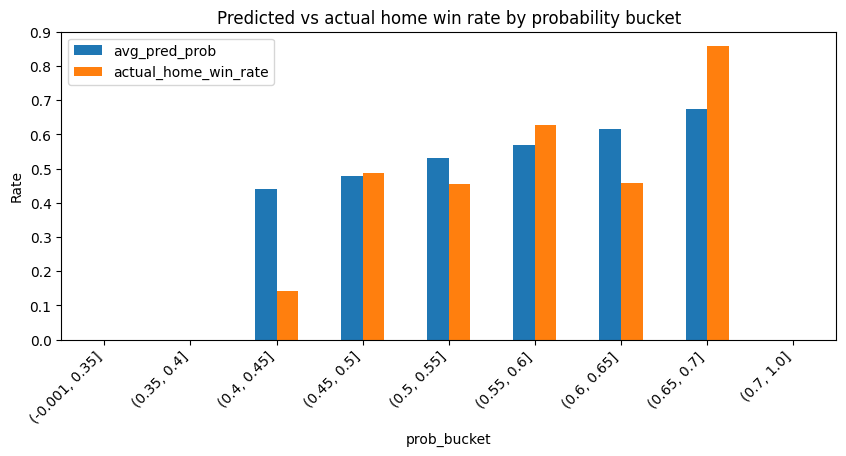

In [19]:
bucket_df = holdout_df.copy()
bucket_df["pred_home_win_prob"] = holdout_proba
bucket_df["prob_bucket"] = pd.cut(
    bucket_df["pred_home_win_prob"],
    bins=[0, .35, .40, .45, .50, .55, .60, .65, .70, 1.0],
    include_lowest=True,
)

bucket_summary = bucket_df.groupby("prob_bucket", observed=False).agg(
    games=("target_home_win", "size"),
    avg_pred_prob=("pred_home_win_prob", "mean"),
    actual_home_win_rate=("target_home_win", "mean"),
)
bucket_summary["calibration_error"] = bucket_summary["actual_home_win_rate"] - bucket_summary["avg_pred_prob"]
display(bucket_summary)

fig, ax = plt.subplots(figsize=(10, 4))
bucket_summary[["avg_pred_prob", "actual_home_win_rate"]].plot(kind="bar", ax=ax)
ax.set_title("Predicted vs actual home win rate by probability bucket")
ax.set_ylabel("Rate")
plt.xticks(rotation=45, ha="right")
plt.show()


## 11. Feature importance

Permutation importance is slower than built-in importances, but it works across model families and reflects out-of-sample prediction impact.


,feature,importance_mean,importance_std
60,diff_run_diff_season_to_date,0.000838,0.000426
64,diff_run_diff_last20,0.000777,0.000414
63,diff_run_diff_last10,0.000557,0.000262
45,diff_win_season_to_date,0.000448,0.000351
55,diff_runs_against_season_to_date,0.000373,0.000178
50,diff_runs_for_season_to_date,0.000372,0.000313
58,diff_runs_against_last10,0.000346,0.000150
59,diff_runs_against_last20,0.000312,0.000159
18,home_run_diff_season_to_date,0.000239,0.000426
22,home_run_diff_last20,0.000227,0.000160


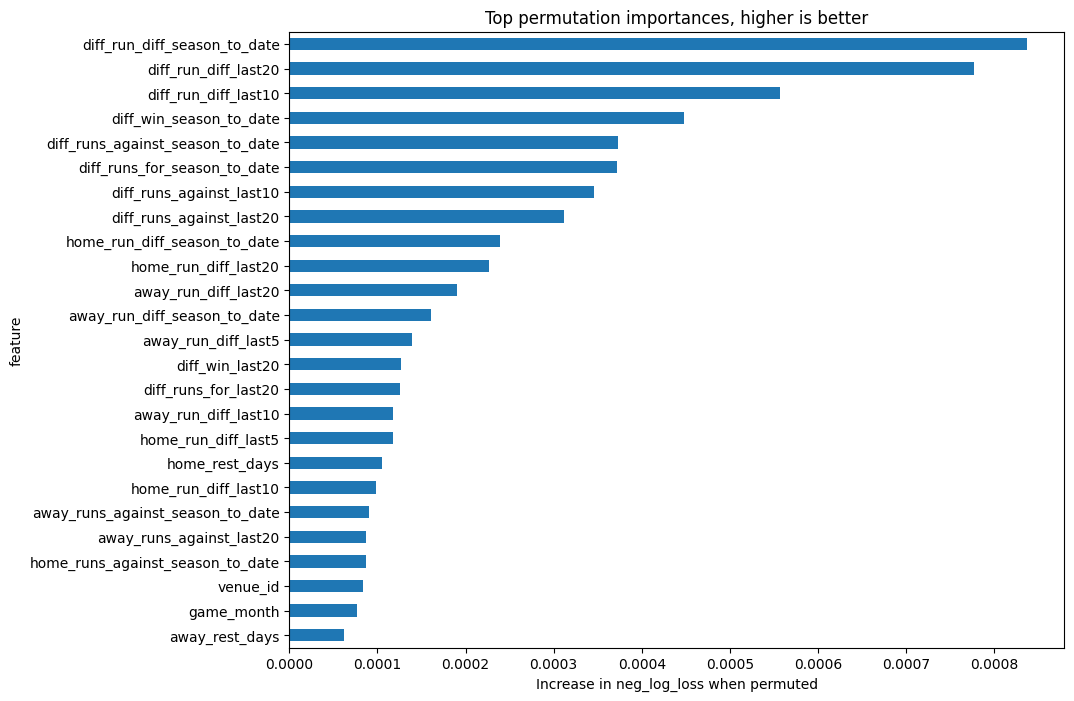

In [20]:
# For speed, sample holdout rows if needed.
importance_sample = holdout_df.copy()
if len(importance_sample) > 750:
    importance_sample = importance_sample.sample(750, random_state=42).sort_values("_split_dt")

X_imp = importance_sample[best_feature_cols]
y_imp = importance_sample["target_home_win"].astype(int)

perm = permutation_importance(
    best_model,
    X_imp,
    y_imp,
    n_repeats=8,
    random_state=42,
    scoring="neg_log_loss",
    n_jobs=-1,
)

importance = pd.DataFrame({
    "feature": best_feature_cols,
    "importance_mean": perm.importances_mean,
    "importance_std": perm.importances_std,
}).sort_values("importance_mean", ascending=False)

display(importance.head(40))

fig, ax = plt.subplots(figsize=(10, 8))
importance.head(25).sort_values("importance_mean").plot(
    x="feature", y="importance_mean", kind="barh", ax=ax, legend=False
)
ax.set_title("Top permutation importances, higher is better")
ax.set_xlabel("Increase in neg_log_loss when permuted")
plt.show()


In [24]:
from sklearn.metrics import accuracy_score, log_loss, brier_score_loss, roc_auc_score
import numpy as np
import pandas as pd

y_true = holdout_df["target_home_win"].astype(int)

home_rate_train = train_df["target_home_win"].mean()
home_baseline_prob = np.repeat(home_rate_train, len(y_true))

print("Train home win rate:", home_rate_train)

print("Baseline log loss:", log_loss(y_true, home_baseline_prob))
print("Baseline Brier:", brier_score_loss(y_true, home_baseline_prob))
print("Always home accuracy:", y_true.mean())

Train home win rate: 0.5359300145802958
Baseline log loss: 0.6946578368905151
Baseline Brier: 0.2507529124848074
Always home accuracy: 0.5074875207986689


### Built-in feature importance for tree/boosting models

Permutation importance is model-agnostic and usually the safest comparison. For XGBoost, LightGBM, Random Forest, Extra Trees, and Histogram Gradient Boosting, we can also inspect built-in importances when available. Treat these as directional diagnostics; they are not causal explanations.


Built-in importance length does not match raw features because the pipeline added imputation indicators. Use permutation importance above for raw feature names.


,feature_or_transformed_index,importance
60,60,0.053152
45,45,0.051366
25,25,0.050146
50,50,0.049154
40,40,0.042996
64,64,0.038174
8,8,0.037913
18,18,0.036387
30,30,0.034202
13,13,0.028381


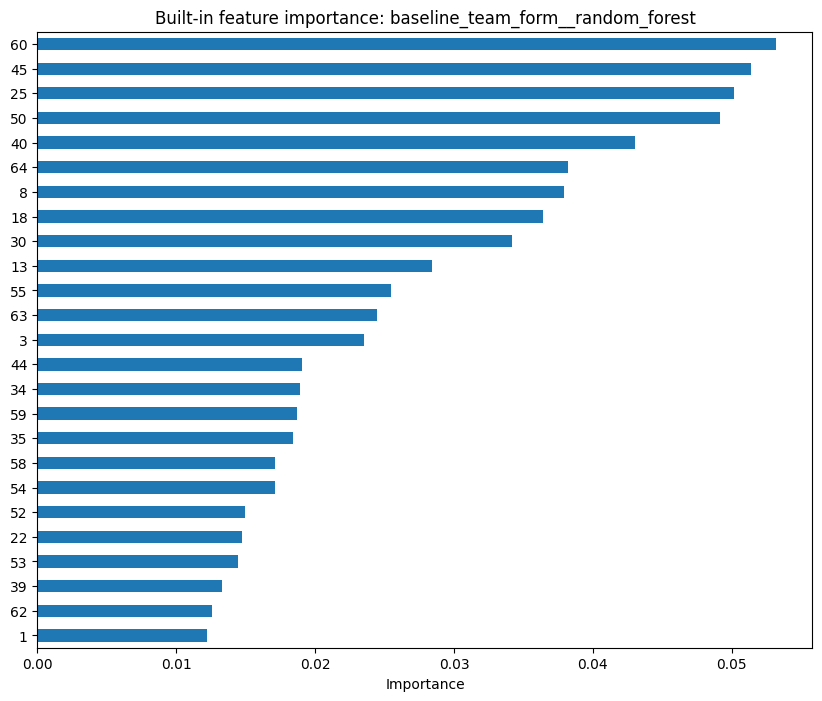

In [21]:
def get_final_estimator(estimator):
    if hasattr(estimator, "named_steps") and "model" in estimator.named_steps:
        return estimator.named_steps["model"]
    return estimator

final_estimator = get_final_estimator(best_model)

if hasattr(final_estimator, "feature_importances_"):
    # Pipeline imputation may add missingness indicators, so the built-in vector can be longer than the raw feature list.
    raw_importances = final_estimator.feature_importances_
    if len(raw_importances) == len(best_feature_cols):
        builtin_importance = pd.DataFrame({
            "feature": best_feature_cols,
            "importance": raw_importances,
        }).sort_values("importance", ascending=False)
    else:
        builtin_importance = pd.DataFrame({
            "feature_or_transformed_index": range(len(raw_importances)),
            "importance": raw_importances,
        }).sort_values("importance", ascending=False)
        print(
            "Built-in importance length does not match raw features because the pipeline added imputation indicators. "
            "Use permutation importance above for raw feature names."
        )

    display(builtin_importance.head(40))
    fig, ax = plt.subplots(figsize=(10, 8))
    plot_col = "feature" if "feature" in builtin_importance.columns else "feature_or_transformed_index"
    builtin_importance.head(25).sort_values("importance").plot(
        x=plot_col, y="importance", kind="barh", ax=ax, legend=False
    )
    ax.set_title(f"Built-in feature importance: {best_key}")
    ax.set_xlabel("Importance")
    ax.set_ylabel("")
    plt.show()
else:
    print(f"{best_key} does not expose feature_importances_. Use permutation importance above.")


## 12. Optional calibration model

If the best model is poorly calibrated, fit a calibration layer. This should be evaluated carefully with time-aware splits. For a production implementation, calibration should be part of the training script after model selection.


In [ ]:
# Holdout is not used here for fitting. We fit calibration on the training data via internal CV.
X_train_best = train_df[best_feature_cols]
y_train_best = train_df["target_home_win"].astype(int)

calibrated = CalibratedClassifierCV(best_model, method="isotonic", cv=3)
calibrated.fit(X_train_best, y_train_best)
calibrated_proba = calibrated.predict_proba(X_holdout)[:, 1]

calibration_compare = pd.DataFrame([
    evaluate_classifier("best_uncalibrated", best_model, X_holdout, y_holdout),
    evaluate_classifier("best_calibrated_isotonic", calibrated, X_holdout, y_holdout),
])
display(calibration_compare)

frac_pos_cal, mean_pred_cal = calibration_curve(y_holdout, calibrated_proba, n_bins=10, strategy="quantile")
fig, ax = plt.subplots(figsize=(6, 6))
ax.plot([0, 1], [0, 1], linestyle="--", linewidth=1)
ax.plot(mean_pred, frac_pos, marker="o", label="uncalibrated")
ax.plot(mean_pred_cal, frac_pos_cal, marker="o", label="calibrated")
ax.set_title("Calibration comparison")
ax.set_xlabel("Mean predicted home win probability")
ax.set_ylabel("Actual home win rate")
ax.legend()
plt.show()


## 13. Betting diagnostics with historical odds, if available

Right now your historical completed rows may not have odds because you only started collecting odds snapshots recently. This section will automatically skip ROI backtesting if historical odds are unavailable.


In [ ]:
def american_to_decimal(price: float) -> float:
    if pd.isna(price):
        return np.nan
    price = float(price)
    return 1 + price / 100 if price > 0 else 1 + 100 / abs(price)


def expected_value(prob: float, american_price: float) -> float:
    dec = american_to_decimal(american_price)
    if pd.isna(prob) or pd.isna(dec):
        return np.nan
    return prob * (dec - 1) - (1 - prob)

bet_df = holdout_df.copy()
bet_df["model_home_win_prob"] = holdout_proba
bet_df["model_away_win_prob"] = 1 - bet_df["model_home_win_prob"]

required_market_cols = {"home_moneyline_median", "away_moneyline_median", "market_home_no_vig_prob", "market_away_no_vig_prob"}
has_market_cols = required_market_cols.issubset(bet_df.columns)

if not has_market_cols or bet_df[list(required_market_cols)].notna().sum().sum() == 0:
    print("No historical market odds found in holdout rows. ROI backtest skipped for now.")
    print("Once odds snapshots accumulate and games complete, rerun this section.")
else:
    bet_df["home_edge"] = bet_df["model_home_win_prob"] - bet_df["market_home_no_vig_prob"]
    bet_df["away_edge"] = bet_df["model_away_win_prob"] - bet_df["market_away_no_vig_prob"]
    bet_df["home_ev"] = [expected_value(p, price) for p, price in zip(bet_df["model_home_win_prob"], bet_df["home_moneyline_median"])]
    bet_df["away_ev"] = [expected_value(p, price) for p, price in zip(bet_df["model_away_win_prob"], bet_df["away_moneyline_median"])]

    rows = []
    for edge_threshold in [0.01, 0.02, 0.03, 0.04, 0.05]:
        for ev_threshold in [0.00, 0.01, 0.02, 0.03]:
            tmp = bet_df.copy()
            tmp["bet_home"] = (tmp["home_edge"] >= edge_threshold) & (tmp["home_ev"] >= ev_threshold)
            tmp["bet_away"] = (tmp["away_edge"] >= edge_threshold) & (tmp["away_ev"] >= ev_threshold)

            bets = []
            for _, r in tmp.iterrows():
                if r["bet_home"]:
                    win = int(r["target_home_win"] == 1)
                    profit = american_to_decimal(r["home_moneyline_median"]) - 1 if win else -1
                    bets.append(profit)
                elif r["bet_away"]:
                    win = int(r["target_home_win"] == 0)
                    profit = american_to_decimal(r["away_moneyline_median"]) - 1 if win else -1
                    bets.append(profit)
            if bets:
                rows.append({
                    "edge_threshold": edge_threshold,
                    "ev_threshold": ev_threshold,
                    "bets": len(bets),
                    "total_profit_units": np.sum(bets),
                    "roi_per_unit": np.mean(bets),
                    "win_rate": np.mean([b > 0 for b in bets]),
                })
    roi_summary = pd.DataFrame(rows).sort_values("roi_per_unit", ascending=False)
    display(roi_summary)


## 14. Upcoming predictions review

This section reads the current production predictions file, if present. It helps validate the Streamlit inputs.


In [ ]:
if PREDICTIONS_PATH.exists():
    preds = pd.read_csv(PREDICTIONS_PATH)
    for col in ["game_datetime_utc", "scored_at_utc"]:
        if col in preds.columns:
            preds[col] = pd.to_datetime(preds[col], errors="coerce", utc=True)
    print("Prediction rows:", len(preds))
    print("Prediction columns:", list(preds.columns))
    display(preds.head(30))

    if "expected_value_per_unit" in preds.columns:
        top = preds[preds["expected_value_per_unit"].notna()].sort_values("expected_value_per_unit", ascending=False).head(10)
        display(top)
else:
    print("No prediction CSV found yet.")


## 15. Recommendations from this QA run

Use this checklist after reviewing the notebook outputs:

1. **If starter features have high missingness:** confirm `scripts/07_fetch_mlb_boxscores.py` populated `mlb_pitcher_game_stats`.
2. **If team-vs-hand features have high missingness:** confirm probable starter hand is available and boxscores were fetched.
3. **If XGBoost/LightGBM are skipped:** install `xgboost` and `lightgbm` in the notebook environment, then rerun from Section 1.
4. **If XGBoost or LightGBM wins by log loss but calibration is poor:** prefer a calibrated version or reduce model complexity.
5. **If the enhanced model does not beat baseline:** inspect feature quality before productionalizing it.
6. **Do not use market fields in training** until you have historical odds coverage for completed games.
7. **Use Streamlit only for serving outputs**, not for retraining models on page load.

A good production candidate should have a strong holdout log loss/Brier score, plausible feature importance, and reasonable calibration. Accuracy alone is not enough for betting recommendations.


In [ ]:
from pathlib import Path
from datetime import datetime, timezone
import json
import shutil
import joblib
import platform
import sklearn
import pandas as pd
import numpy as np


def get_project_root() -> Path:
    """
    Handles running from:
    - project root
    - notebooks/
    - GitHub Codespaces
    """
    cwd = Path.cwd().resolve()

    if cwd.name == "notebooks":
        return cwd.parent

    if (cwd / "notebooks").exists() and (cwd / "models").exists():
        return cwd

    for parent in cwd.parents:
        if (parent / "notebooks").exists() and (parent / "models").exists():
            return parent

    return cwd


PROJECT_ROOT = get_project_root()
MODEL_DIR = PROJECT_ROOT / "models"
MODEL_DIR.mkdir(parents=True, exist_ok=True)

print("Project root:", PROJECT_ROOT)
print("Model dir:", MODEL_DIR)


def export_champion_model(
    estimator,
    feature_cols,
    metrics,
    model_family,
    feature_set_name,
    notes="",
    target_col="target_home_win",
    model_dir=MODEL_DIR,
):
    """
    Saves the selected model to a stable production path.

    GitHub Actions will always load:
        models/mlb_moneyline_champion.joblib
    """

    created_at = datetime.now(timezone.utc).strftime("%Y-%m-%dT%H:%M:%SZ")
    timestamp = datetime.now(timezone.utc).strftime("%Y%m%d_%H%M%S")

    champion_path = model_dir / "mlb_moneyline_champion.joblib"
    metadata_path = model_dir / "mlb_moneyline_champion_metadata.json"

    archive_dir = model_dir / "archive"
    archive_dir.mkdir(parents=True, exist_ok=True)

    archive_path = archive_dir / f"mlb_moneyline_{model_family}_{timestamp}.joblib"
    archive_metadata_path = archive_dir / f"mlb_moneyline_{model_family}_{timestamp}_metadata.json"

    metadata = {
        "model_name": "mlb_moneyline_champion",
        "model_family": model_family,
        "feature_set_name": feature_set_name,
        "target_col": target_col,
        "feature_count": len(feature_cols),
        "feature_cols": list(feature_cols),
        "metrics": metrics,
        "notes": notes,
        "created_at_utc": created_at,
        "python_version": platform.python_version(),
        "sklearn_version": sklearn.__version__,
        "pandas_version": pd.__version__,
        "numpy_version": np.__version__,
    }

    bundle = {
        "model_name": "mlb_moneyline_champion",
        "estimator": estimator,
        "feature_cols": list(feature_cols),
        "target_col": target_col,
        "model_family": model_family,
        "feature_set_name": feature_set_name,
        "metrics": metrics,
        "metadata": metadata,
        "created_at_utc": created_at,
    }

    joblib.dump(bundle, champion_path)
    joblib.dump(bundle, archive_path)

    metadata_path.write_text(json.dumps(metadata, indent=2), encoding="utf-8")
    archive_metadata_path.write_text(json.dumps(metadata, indent=2), encoding="utf-8")

    print("Saved champion model:", champion_path)
    print("Saved champion metadata:", metadata_path)
    print("Saved archived model:", archive_path)

    return champion_path, metadata_path